In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ranaghulamnabi/stroke-risk-dataset/healthcare-dataset-stroke-data.csv


# **Table of Contents**
**✅ Import Packages.**   
**✅ Data Import & EDA.**   
**✅ Data Visualization.**   
**✅ Data Preprocessing.**    
**✅ ML.**   

# **Import Packages.**

In [2]:
#Data Handling & Visualize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import time

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

# **Data Import & EDA.**

In [3]:
df = pd.read_csv('/kaggle/input/datasets/ranaghulamnabi/stroke-risk-dataset/healthcare-dataset-stroke-data.csv')

**Description**    
This dataset contains healthcare-related information used to analyze and predict the likelihood of stroke occurrence in patients. It includes demographic details, medical history, and lifestyle factors that play a significant role in stroke risk assessment. The dataset is suitable for machine learning tasks such as classification, feature engineering, and exploratory data analysis.

[Link](https://www.kaggle.com/datasets/ranaghulamnabi/stroke-risk-dataset/data) <<<

In [4]:
# traindata summary 
print(f'{df.info()}')
print('-'* 60)
print(f'df summary \n{df.describe().T}')
print('-'* 60)

#Missing Value & Duplicate Value Check
print(pd.DataFrame(df.isna().sum().reset_index(name='Na')))
print('-'* 60)
print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB
None
------------------------------------------------------------
df summary 
                    count          mean           std    min        25%  \
id  

In [5]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# **Data Visualization**

In [6]:
cols = ['hypertension','heart_disease','stroke']

for i in cols :
    df[i] = df[i].astype(object)

In [7]:
num_cols = df.select_dtypes(include = {'int64', 'float64'}).columns
cat_cols = df.select_dtypes(exclude = {'int64', 'float64'}).columns

### **Histogram**

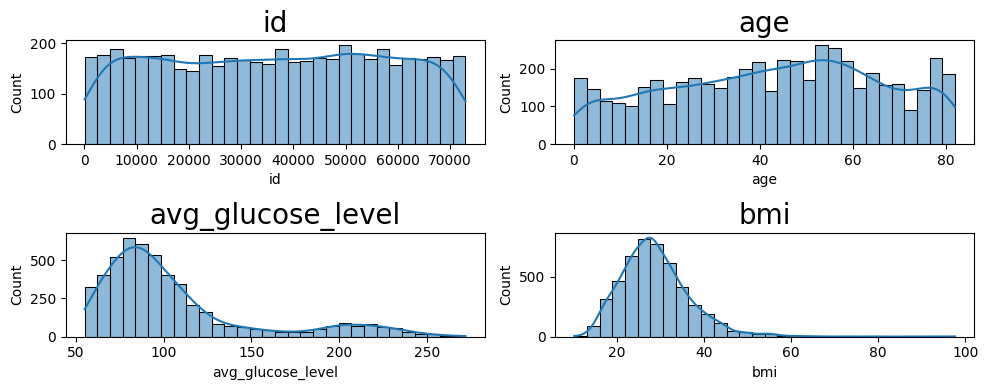

In [8]:
num_rows = (len(num_cols) + 1) // 2

f, ax = plt.subplots(2,2, figsize=(10,2 * num_rows))
ax = ax.flatten()

for index, cols in enumerate(num_cols):
    sns.histplot(data = df, x= cols, ax = ax[index],kde=True, bins=30)
    ax[index].set_title(cols, size = 20)

plt.tight_layout()
plt.show()

### **Boxplot**

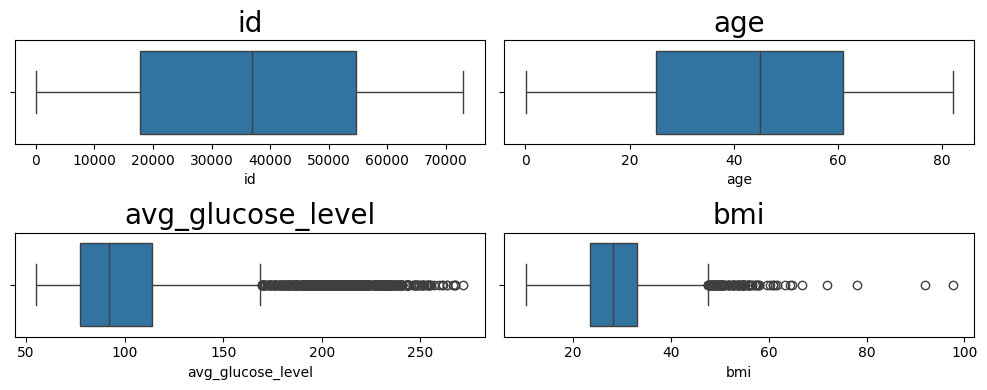

In [9]:
num_rows = (len(num_cols) + 1) // 2

f, ax = plt.subplots(2,2, figsize=(10,2 * num_rows))
ax = ax.flatten()

for index, cols in enumerate(num_cols):
    sns.boxplot(df, x= cols , ax= ax[index])
    ax[index].set_title(cols, size=20)
    
    
plt.tight_layout()
plt.show()

### **CountPlot**

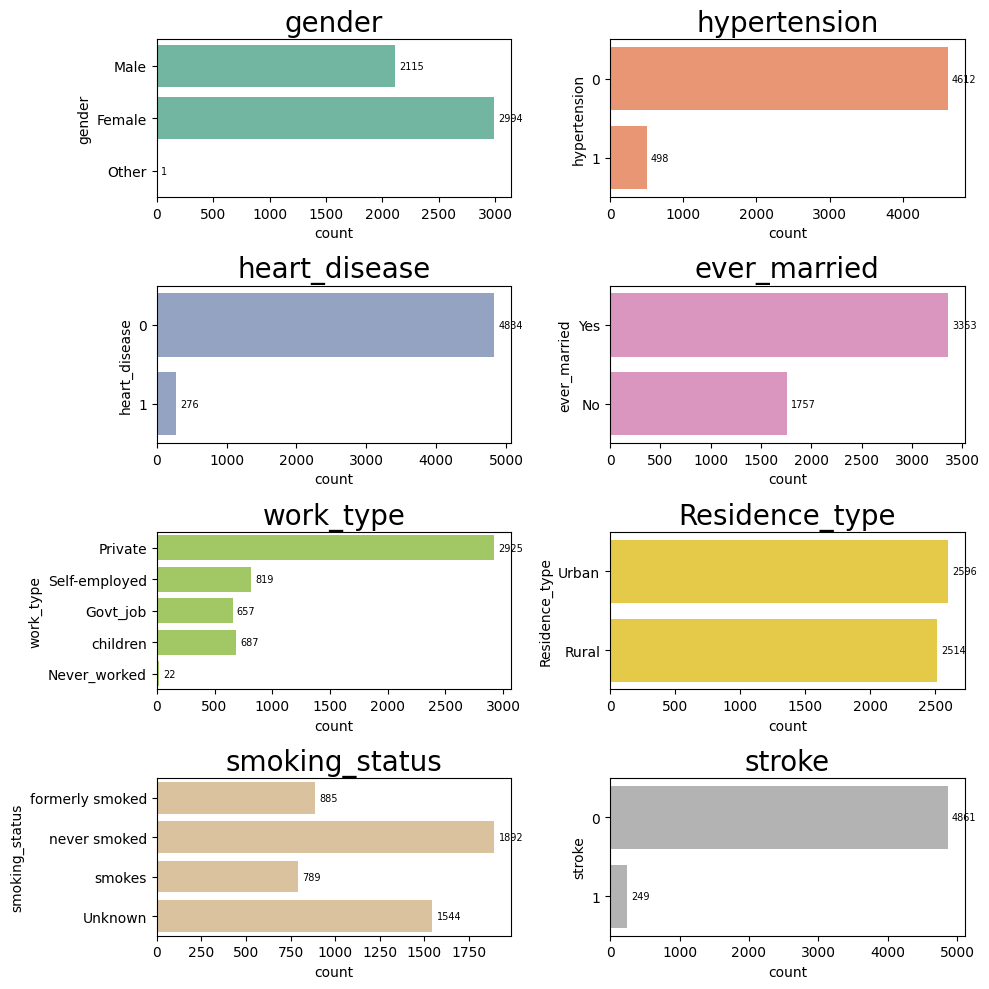

In [10]:
cat_rows = (len(cat_cols) + 1) // 2
palette = sns.color_palette("Set2", len(cat_cols))
f, ax = plt.subplots(4,2, figsize=(10,5 * num_rows))
ax = ax.flatten()

for index, cols in enumerate(cat_cols):
    sns.countplot(df, y = cols , ax= ax[index],color=palette[index])
    ax[index].set_title(cols, size=20)
    for container in ax[index].containers:
        ax[index].bar_label(container, fontsize=7, padding=3)
        
plt.tight_layout()
plt.show()

### **Correlation**

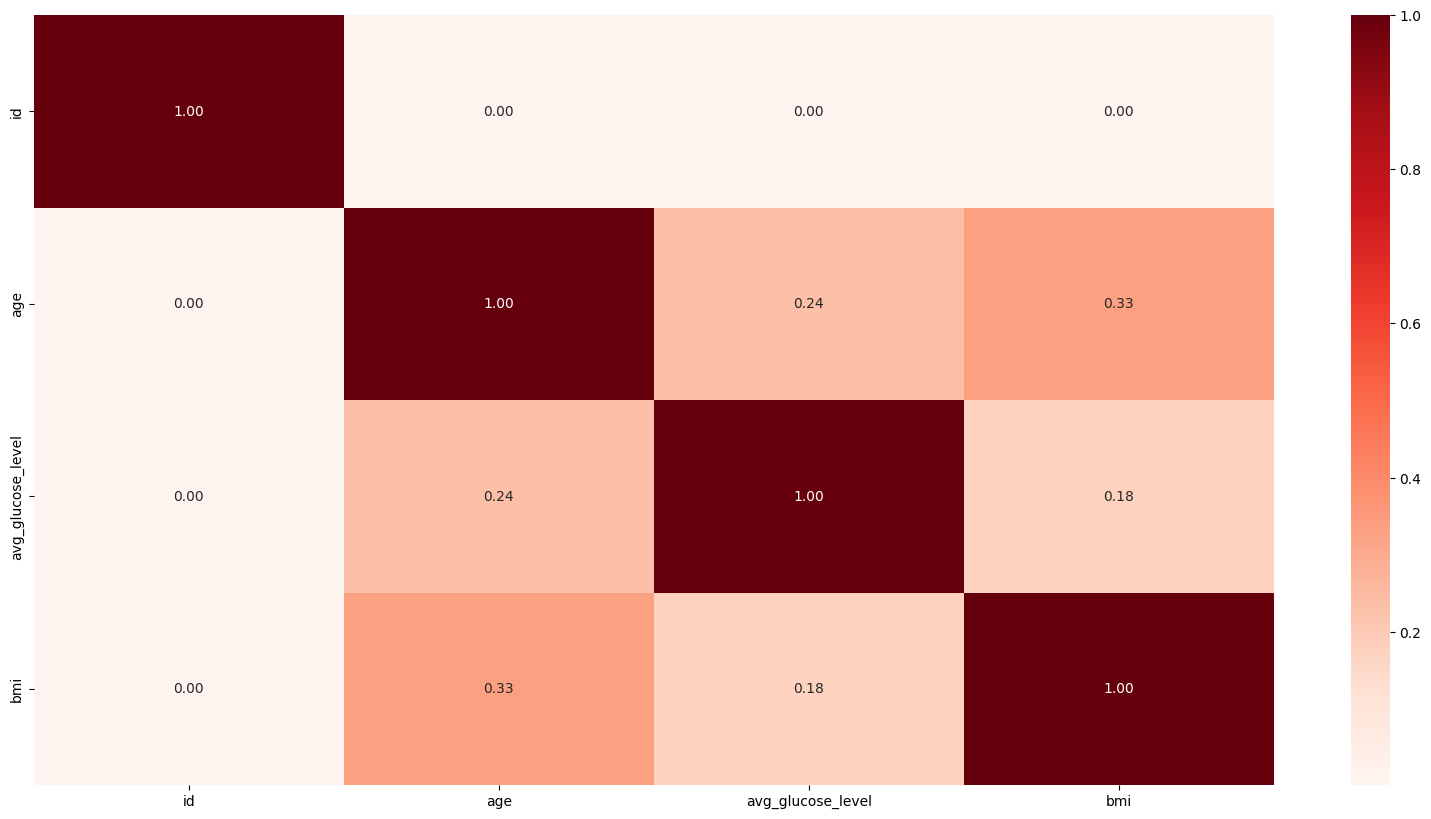

In [11]:
plt.figure(figsize=(20, 10))
sns.heatmap(df[num_cols].corr(),annot=True, cmap='Reds',fmt= '.2f')
plt.show()

# **ML Modeling**

In [12]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier 
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score , f1_score, roc_curve 

## **Preprocessing**

In [13]:
#preprocessing

df['bmi'] = df['bmi'].fillna(df['bmi'].mean())
df.drop(columns = 'id',inplace = True)

In [14]:
#Label Encoding

label_encoder = LabelEncoder()
label_mappings = {}

for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])
    label_mappings[col] = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

for col, mapping in label_mappings.items():
    print(f"Column: {col}")
    for label, code in mapping.items():
        print(f"{label} -> {code}")
    print()

Column: gender
Female -> 0
Male -> 1
Other -> 2

Column: hypertension
0 -> 0
1 -> 1

Column: heart_disease
0 -> 0
1 -> 1

Column: ever_married
No -> 0
Yes -> 1

Column: work_type
Govt_job -> 0
Never_worked -> 1
Private -> 2
Self-employed -> 3
children -> 4

Column: Residence_type
Rural -> 0
Urban -> 1

Column: smoking_status
Unknown -> 0
formerly smoked -> 1
never smoked -> 2
smokes -> 3

Column: stroke
0 -> 0
1 -> 1



### **Train Test Split**

In [15]:
x = df.drop(columns=['stroke'])
y = df['stroke']

In [16]:
x_train, x_test, y_train, y_test =train_test_split(x, y , random_state = 42, test_size= 0.2)

### **SMOTE(Over Sampling)**

In [17]:
smote = SMOTE(random_state=42)

In [18]:
X_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

## **Basic Model**

In [19]:
lgr = LogisticRegression()
rfc = RandomForestClassifier(random_state=42)
abc = AdaBoostClassifier(random_state=42)
gbc = GradientBoostingClassifier(random_state=42)
xgb = XGBClassifier(random_state=42)

models = [lgr, rfc, abc, gbc, xgb]

names = ["Logistic Regression","Random Forest", "Ada Boost",
        "Gradient Boostng", "XGBoost"]

Logistic Regression accuracy: 0.775
              precision    recall  f1-score   support

           0       0.97      0.79      0.87       960
           1       0.15      0.58      0.24        62

    accuracy                           0.77      1022
   macro avg       0.56      0.68      0.55      1022
weighted avg       0.92      0.77      0.83      1022



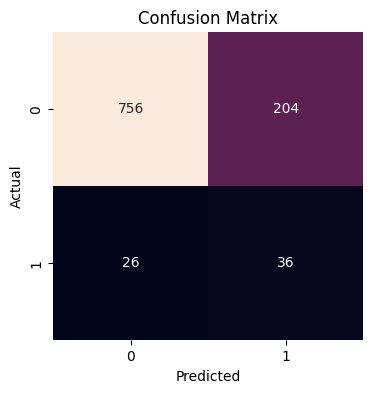

--------------------------------------------------
Random Forest accuracy: 0.9012
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       960
           1       0.17      0.16      0.17        62

    accuracy                           0.90      1022
   macro avg       0.56      0.56      0.56      1022
weighted avg       0.90      0.90      0.90      1022



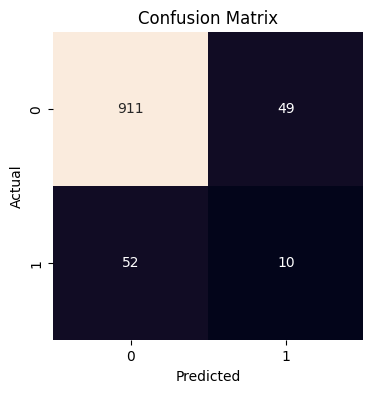

--------------------------------------------------
Ada Boost accuracy: 0.7524
              precision    recall  f1-score   support

           0       0.97      0.76      0.85       960
           1       0.15      0.65      0.24        62

    accuracy                           0.75      1022
   macro avg       0.56      0.70      0.55      1022
weighted avg       0.92      0.75      0.82      1022



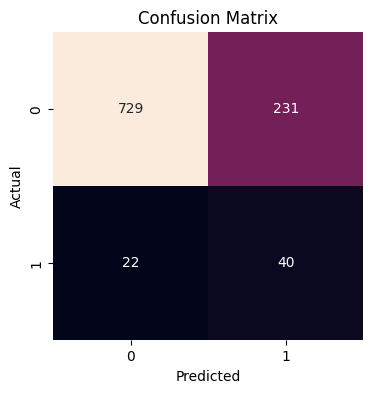

--------------------------------------------------
Gradient Boostng accuracy: 0.8337
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       960
           1       0.16      0.42      0.23        62

    accuracy                           0.83      1022
   macro avg       0.56      0.64      0.57      1022
weighted avg       0.91      0.83      0.87      1022



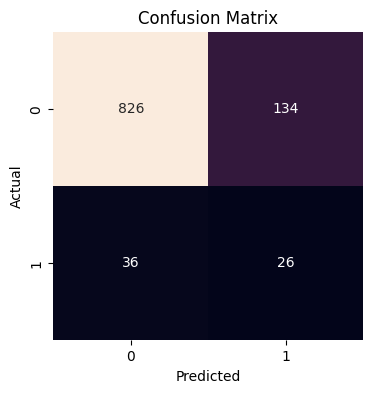

--------------------------------------------------
XGBoost accuracy: 0.8933
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       960
           1       0.15      0.16      0.16        62

    accuracy                           0.89      1022
   macro avg       0.55      0.55      0.55      1022
weighted avg       0.90      0.89      0.90      1022



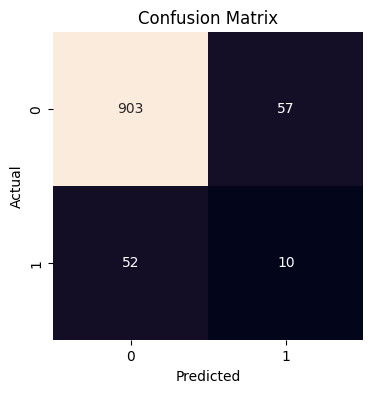

--------------------------------------------------


In [20]:
index = 0
ac = []
f1_list = []
roc_data  = []

for name, model in enumerate(models):
    model.fit(X_train_smote, y_train_smote)
    pred = model.predict(x_test)
    
    accuracy = accuracy_score(y_test, pred)
    ac.append(accuracy)
    
    f1 = f1_score(y_test, pred)
    f1_list.append(f1)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(x_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(x_test)
    else:
        y_score = None

    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_test, y_score)
        auc_score = roc_auc_score(y_test, y_score)

        roc_data.append({
            "name": names[index],
            "fpr": fpr,
            "tpr": tpr,
            "auc": auc_score
        })

    
    cm = confusion_matrix(y_test, pred)
    print(f'{names[index]} accuracy: {round(accuracy,4)}')
    print(classification_report(y_test, pred))
 
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    
    print("-"*50)
    
    index += 1

## **Model Comparison**

In [21]:
acc_df = pd.DataFrame({'Model': names, 'Accuracy': ac})
acc_df['Accuracy'] = acc_df['Accuracy']*100
acc_df

,Model,Accuracy
0,Logistic Regression,77.495108
1,Random Forest,90.117417
2,Ada Boost,75.244618
3,Gradient Boostng,83.365949
4,XGBoost,89.334638


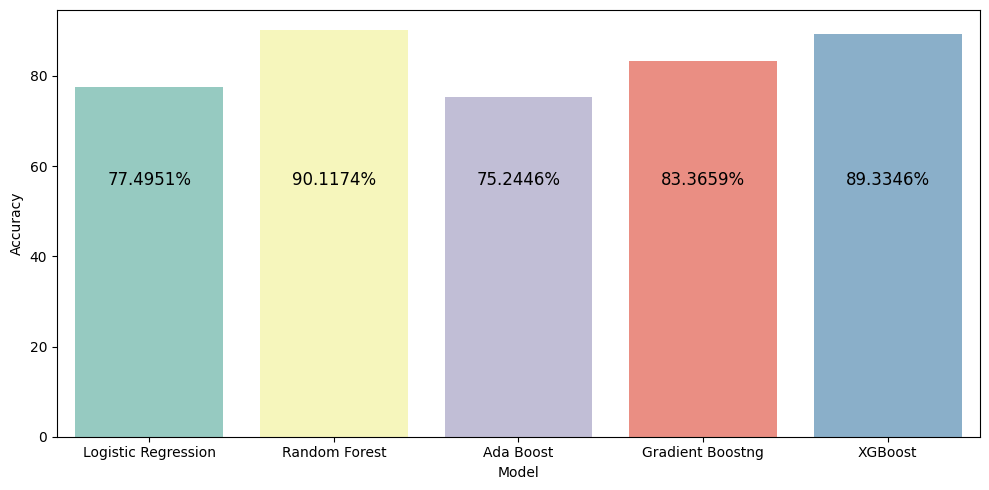

In [22]:
plt.subplots(figsize=(10,5))
palette = sns.color_palette("Set3")
sns.barplot(acc_df, x= 'Model', y = 'Accuracy', palette = palette)

for index, value in enumerate(ac):
    plt.text(index, value + 55, f"{value*100:.4f}%", ha='center', fontsize=12)
    
plt.tight_layout()
plt.show()

### **f1_score & ROC CURVE**

In [23]:
f1_df = pd.DataFrame({'Model': names, 'f1_score': f1_list})
f1_df['f1_score'] = f1_df['f1_score']*100
f1_df

,Model,f1_score
0,Logistic Regression,23.841060
1,Random Forest,16.528926
2,Ada Boost,24.024024
3,Gradient Boostng,23.423423
4,XGBoost,15.503876


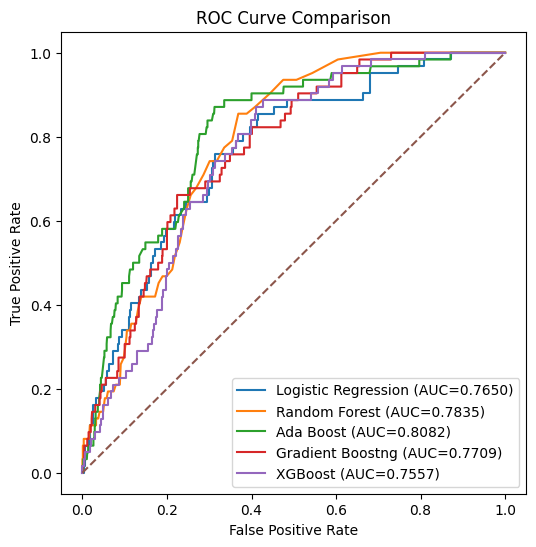

In [24]:
plt.figure(figsize=(6, 6))

for data in roc_data:
    plt.plot(
        data["fpr"],
        data["tpr"],
        label=f'{data["name"]} (AUC={data["auc"]:.4f})'
    )

plt.plot([0, 1], [0, 1], linestyle='--')  # baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

**AdaBoost is the best model.**    
**AdaBoost is less accuracy than RandomForest, but f1_score, roc_curve is higher for unbalanced classes..**   


### **Threshold tune (basic : 0.5)**

In [25]:
model = AdaBoostClassifier(random_state=42)
model.fit(X_train_smote, y_train_smote)

y_score = model.predict_proba(x_test)[:, 1]

for threshold in [0.5, 0.48]:
    pred = (y_score >= threshold).astype(int)

    print(f'[threshold = {threshold}]')
    print(f'accuracy: {accuracy_score(y_test, pred):.4f}')
    print(f'f1 score: {f1_score(y_test, pred):.4f}')
    print(classification_report(y_test, pred))
    print('-' * 50)

[threshold = 0.5]
accuracy: 0.7524
f1 score: 0.2402
              precision    recall  f1-score   support

           0       0.97      0.76      0.85       960
           1       0.15      0.65      0.24        62

    accuracy                           0.75      1022
   macro avg       0.56      0.70      0.55      1022
weighted avg       0.92      0.75      0.82      1022

--------------------------------------------------
[threshold = 0.48]
accuracy: 0.7123
f1 score: 0.2613
              precision    recall  f1-score   support

           0       0.99      0.70      0.82       960
           1       0.15      0.84      0.26        62

    accuracy                           0.71      1022
   macro avg       0.57      0.77      0.54      1022
weighted avg       0.94      0.71      0.79      1022

--------------------------------------------------


**When threshold was 0.48, The accuracy dropped. But the f1_score of the unbalanced class went up.**


---------
**Thankyou, Please leave your advice in the comments**
